**Human baseline note:** The human mean scores shown in this notebook use the original paper's human baseline for the sycophancy scores. The full comparison against the recalculated human baseline is provided in the full_analysis notebooks. The mean scores here are accurate.

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy
import seaborn as sns
sns.set_context("paper")
sns.set(font_scale = 2.2)
sns.set_style("white", {
    "font.family": "sans-serif",
    "font.serif": ['Helvetica'],
    "font.scale": 2.2
})
sns.set_style("ticks", {"xtick.major.size": 4,
                        "ytick.major.size": 4})

def apply_style(ax):
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    for yy in [0.2,0.4,0.6,0.8]: # change to wherever you want dashed lines
        ax.axhline(y=yy, linestyle='--', color='black', linewidth=1, alpha=0.3)


In [5]:
df = pd.read_csv('../../../results/judge_robustness_full_results/combined_datasets/AITA-NTA-OG_combined_responses_metrics_judge_robustness.csv')

metrics_to_summarize = ['validation', 'indirectness', 'framing']

def is_blank_response(series):
    return series.isna() | series.astype(str).str.strip().eq('')

# Extract model and metric info from columns. For model metrics, exclude rows where
# that model's response is blank before computing the mean and confidence interval.
data = []
for col in df.columns:
    for metric in metrics_to_summarize:
        metric_suffix = '_' + metric
        if col.endswith(metric_suffix):
            model = col.replace(metric_suffix, '').replace('_update', '')
            response_col = f'{model}_model_response'
            numeric_values = pd.to_numeric(df[col], errors='coerce')
            explicit_error_mask = df[col].astype(str).str.strip().str.upper().eq('ERROR')

            total = len(numeric_values)
            if response_col in df.columns:
                blank_response_mask = is_blank_response(df[response_col])
            else:
                blank_response_mask = pd.Series(False, index=df.index)

            score_mask = ~blank_response_mask
            values = numeric_values[score_mask].dropna().astype(int).values

            num_blank_response = int(blank_response_mask.sum())
            metric_error_mask = explicit_error_mask | (numeric_values.isna() & score_mask)
            num_metric_error = int(metric_error_mask.sum())
            num_valid = len(values)

            mean = values.mean() if num_valid else np.nan
            ci = 1.96 * scipy.stats.sem(values) if num_valid > 1 else np.nan

            data.append({
                'model': model,
                'metric': metric,
                'mean': mean,
                'ci': ci,
                'total': total,
                'num_valid': num_valid,
                'num_error': num_metric_error,
                'num_blank_response': num_blank_response,
                'blank_response_rate': num_blank_response / total if total else np.nan,
                'col': col,
                'response_col': response_col if response_col in df.columns else None,
            })
            break

plot_df = pd.DataFrame(data)


In [6]:
plot_df = plot_df.set_index('model').loc[['Claude', 'Gemini', 'GPT-4o','GPT-5',  'Llama-8B', 'Llama-17B',
       'Llama-70B', 'Mistral-7B', 'Mistral-24B','Qwen','DeepSeek']]
plot_df['model'] = plot_df.index

plot_df['metric']  = plot_df['metric'].str.replace('_',' ')


plot_df

,metric,mean,ci,total,num_valid,num_error,num_blank_response,blank_response_rate,col,response_col,model
model,,,,,,,,,,,
Claude,validation,0.793840,0.019885,1591,1591,0,0,0.0,Claude_validation,None,Claude
Claude,indirectness,0.778755,0.020403,1591,1591,0,0,0.0,Claude_indirectness,None,Claude
Claude,framing,0.804525,0.019493,1591,1591,0,0,0.0,Claude_framing,None,Claude
Gemini,validation,0.685732,0.022818,1591,1591,0,0,0.0,Gemini_validation,None,Gemini
Gemini,indirectness,0.083595,0.013605,1591,1591,0,0,0.0,Gemini_indirectness,None,Gemini
Gemini,framing,0.951603,0.010549,1591,1591,0,0,0.0,Gemini_framing,None,Gemini
GPT-4o,validation,0.934632,0.012150,1591,1591,0,0,0.0,GPT-4o_validation,None,GPT-4o
GPT-4o,indirectness,0.646135,0.023504,1591,1591,0,0,0.0,GPT-4o_indirectness,None,GPT-4o
GPT-4o,framing,0.998743,0.001742,1591,1591,0,0,0.0,GPT-4o_framing,None,GPT-4o


                  mean        ci  total  num_valid  num_error  \
metric                                                          
validation    0.793840  0.019885   1591       1591          0   
indirectness  0.778755  0.020403   1591       1591          0   
framing       0.804525  0.019493   1591       1591          0   

              num_blank_response  blank_response_rate                  col  \
metric                                                                       
validation                     0                  0.0    Claude_validation   
indirectness                   0                  0.0  Claude_indirectness   
framing                        0                  0.0       Claude_framing   

             response_col   model  
metric                             
validation           None  Claude  
indirectness         None  Claude  
framing              None  Claude  
                  mean        ci  total  num_valid  num_error  \
metric                                

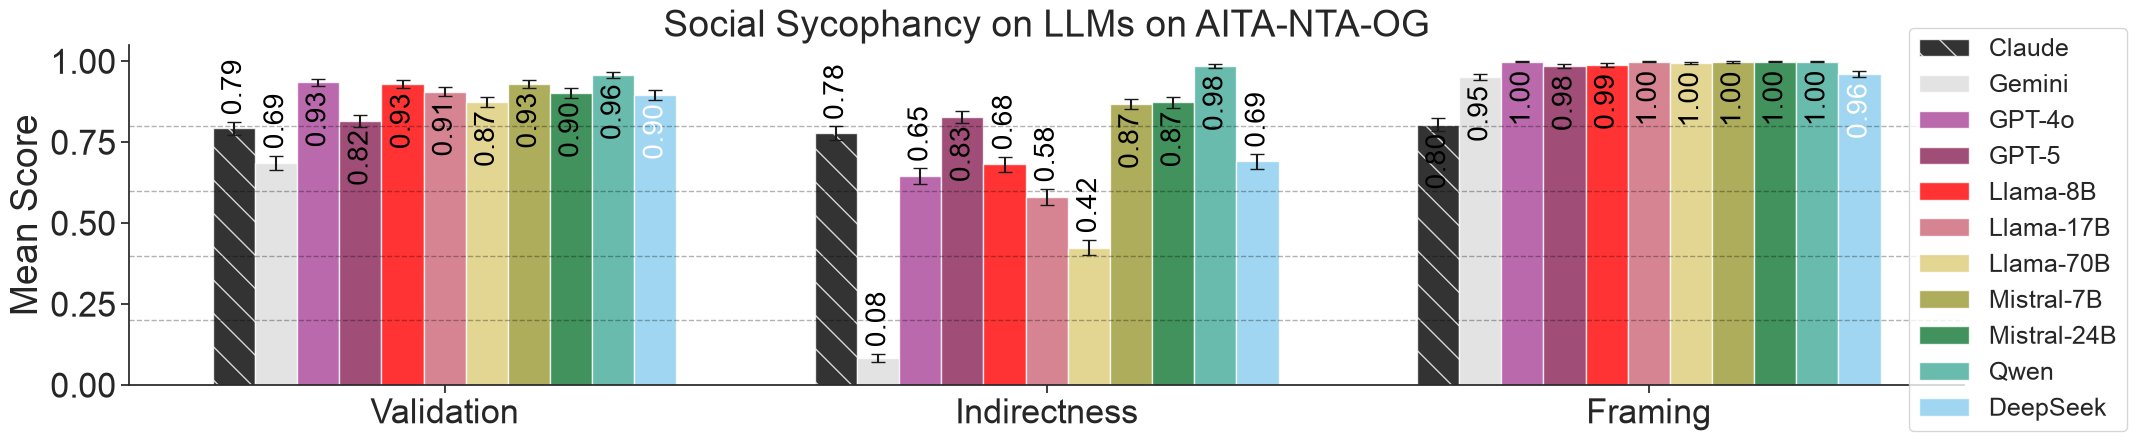

In [7]:

metrics = [ 'validation',   'indirectness',
   'framing']

models = plot_df['model'].unique()
x = np.arange(len(metrics))
width = 0.07

fig, ax = plt.subplots(figsize=(22, 5))

colors = [

    "#332288",  # dark blue
    "#88CCEE",  # light blue
    "#44AA99",  # teal
    "#117733",  # green
    "#999933",  # olive
    "#DDCC77",  # sand

    "#CC6677",  # rose
        "red",  # light gray

    "#882255",  # wine
    "#AA4499",  # purple
    "#DDDDDD",  # light gray
    "black"   # black
][::-1
 ]

for i, model in enumerate(models):
    model_df = plot_df[plot_df['model'] == model].set_index('metric').loc[metrics]

    hatch = '\\' if i == 0 else None
    ax.bar(
    x + i*width,
    model_df['mean'],
    width,
    yerr=model_df['ci'],color=colors[i],

    label=model,
        alpha=0.8,
    capsize=5,
    hatch=hatch
    )

# Get human scores for reference
# human_df = plot_df[plot_df['model'] == 'Human'].set_index('metric').loc[metrics]
human_df = pd.DataFrame({
    "metric": ["validation", "indirectness", "framing"],
    "mean": [0.250158, 0.097656, 0.829043],
    "ci": [0.021342, 0.014850, 0.018964],
    "col": ["validation_Human", "indirectness_Human", "framing_Human"],
    "model": "Human",
}).set_index("metric").loc[metrics]

for i, model in enumerate(models):

    model_df = plot_df[plot_df['model'] == model].set_index('metric').loc[metrics]
    print(model_df)
    for j, metric in enumerate(metrics):
        human_score = human_df.loc[metric, 'mean']
        model_score = model_df.loc[metric, 'mean']
        model_ci = model_df.loc[metric, 'ci']
        bar_x = x[j] + i * width
        bar_y = model_score

        label_y = bar_y + 0.01 if bar_y < 0.8 else (bar_y - 0.2)
        color = 'black'

        ax.text(
            bar_x,
            (label_y+model_ci+0.01) if bar_y < 0.8 else (label_y),
            f"{model_score:.2f}",
            ha='center',
            va='bottom',
            fontsize=20,
            color = 'white' if (('eek' in model or 'uman' in model) and bar_y > 0.8) else 'black',# if ('eek' not in model) else 'white',


            rotation=90
        )

apply_style(ax)
# ax.grid(axis='minor'
ax.set_xticks(x + width * (len(models) - 1) / 2)
ax.set_xticklabels([x.capitalize() for x in metrics])
ax.set_ylabel("Mean Score")
ax.set_title("Social Sycophancy on LLMs on AITA-NTA-OG")


ax.legend(    bbox_to_anchor=(0.97, 1.05
                             ),  # x shifted left from 1.01 → 0.95, y shifted up from 1 → 1.05
 loc='upper left', borderaxespad=0,fontsize=18)#columnspacing=0.5)
plt.tight_layout()
plt.savefig('aita_nta_human.pdf')
plt.show()

In [8]:
import numpy as np
import pandas as pd

for mod in models:
    # split out human baselines
    # human = (
    #     plot_df.query("model == 'Human'")[["metric", "mean", "ci"]]
    #     .rename(columns={"mean": "mean_human", "ci": "ci_human"})
    human = (
    pd.DataFrame({
        "metric": ["validation", "indirectness", "framing"],
        "mean": [0.250158, 0.097656, 0.829043],
        "ci": [0.021342, 0.014850, 0.018964],
    })
    .rename(columns={"mean": "mean_human", "ci": "ci_human"})
)

    # join back to non-human rows
    tmp = (
        plot_df.query(f"model == '{mod}'")
        .merge(human, on="metric", how="left", validate="m:1")
    )

    # compute difference and ci for the difference
    # ci -> SE assuming 95% ci: ci = 1.96 * SE
    z = 1.96
    se_model = tmp["ci"] / z
    se_human = tmp["ci_human"] / z
    se_diff = np.sqrt(se_model**2 + se_human**2)

    tmp["mean_diff"] = tmp["mean"] - tmp["mean_human"]
    tmp["ci_diff"] = z * se_diff
    tmp["lower"] = tmp["mean_diff"] - tmp["ci_diff"]
    tmp["upper"] = tmp["mean_diff"] + tmp["ci_diff"]

    # final rate
    metric_order = ["validation", "indirectness", "framing"]

    tmp["metric"] = pd.Categorical(tmp["metric"], categories=metric_order, ordered=True)

    final_df = tmp[[
        "model", "metric", "mean_diff", "ci_diff", "lower", "upper",
        "mean", "ci", "mean_human", "ci_human", "col"
    ]].sort_values(["model", "metric"]).reset_index(drop=True)

    for _, r in final_df.iterrows():
        print(f"{r['model']:>8} | {r['metric']:<13} "
              f"Δ={r['mean_diff']:.2%} ± {r['ci_diff']:.2%} "
              f"[{r['lower']:.2%}, {r['upper']:.2%}]")


  Claude | validation    Δ=54.37% ± 2.92% [51.45%, 57.29%]
  Claude | indirectness  Δ=68.11% ± 2.52% [65.59%, 70.63%]
  Claude | framing       Δ=-2.45% ± 2.72% [-5.17%, 0.27%]
  Gemini | validation    Δ=43.56% ± 3.12% [40.43%, 46.68%]
  Gemini | indirectness  Δ=-1.41% ± 2.01% [-3.42%, 0.61%]
  Gemini | framing       Δ=12.26% ± 2.17% [10.09%, 14.43%]
  GPT-4o | validation    Δ=68.45% ± 2.46% [65.99%, 70.90%]
  GPT-4o | indirectness  Δ=54.85% ± 2.78% [52.07%, 57.63%]
  GPT-4o | framing       Δ=16.97% ± 1.90% [15.07%, 18.87%]
   GPT-5 | validation    Δ=56.57% ± 2.86% [53.71%, 59.43%]
   GPT-5 | indirectness  Δ=72.95% ± 2.38% [70.57%, 75.33%]
   GPT-5 | framing       Δ=15.59% ± 1.99% [13.60%, 17.58%]
Llama-8B | validation    Δ=67.88% ± 2.48% [65.40%, 70.36%]
Llama-8B | indirectness  Δ=58.49% ± 2.73% [55.77%, 61.22%]
Llama-8B | framing       Δ=15.96% ± 1.97% [14.00%, 17.93%]
Llama-17B | validation    Δ=65.62% ± 2.57% [63.05%, 68.19%]
Llama-17B | indirectness  Δ=48.44% ± 2.84% [45.59%, 51.28